### Paso 1.- Importar Librerias

In [36]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report, roc_auc_score)

### Paso 2.- Cargar Dataset

In [38]:
# ─── Cargar el dataset ────────────────────────────────────────────────────────
# 📌 ACCIÓN: Cambia la ruta al lugar donde tienes guardado el CSV
# Descarga el dataset desde: /data/processed/coffee_quality_clean.csv
# La ruta no modificarla. Y poner el mismo nombre todos.

df = pd.read_csv('../data/processed/coffee_quality_clean.csv')

print(f'✅ Datasets cargados correctamente')
print(f'📊 Dimensiones df: {df.shape[0]} filas x {df.shape[1]} columnas')

✅ Datasets cargados correctamente
📊 Dimensiones df: 1518 filas x 18 columnas


### Paso 3.- Preprocesamiento de Datos

#### Qué hacer con las siguientes columnas : Country of Origin, Altitude, Harvest Year, Variety, Processing Method y Color

#### Mantengo Altitude y Color y borro las demás junto a Uniformity, Clean Cup y Sweetness

In [39]:
# ─── DECISIÓN: Qué columnas eliminar ─────────────────────────────────────────
# Estas columnas son metadata (identificadores, nombres) que no aportan al modelo
# 📌 ACCIÓN: Revisa la lista de columnas y ajusta eliminando lo que consideres
df = df.drop(['Country of Origin', 'Harvest Year', 'Variety', 'Processing Method', 'Uniformity', 'Clean Cup', 'Sweetness'], axis=1)

In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1518 entries, 0 to 1517
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Altitude              1290 non-null   str    
 1   Aroma                 1518 non-null   float64
 2   Flavor                1518 non-null   float64
 3   Aftertaste            1518 non-null   float64
 4   Acidity               1518 non-null   float64
 5   Body                  1518 non-null   float64
 6   Balance               1518 non-null   float64
 7   Category One Defects  1518 non-null   int64  
 8   Color                 1251 non-null   str    
 9   Category Two Defects  1518 non-null   int64  
 10  Specialty             1518 non-null   str    
dtypes: float64(6), int64(2), str(3)
memory usage: 130.6 KB


#### Borro columnas Altitude y Color para hacer pruebas antes de hacer label-encoding

In [41]:
df = df.drop(['Altitude', 'Color'], axis=1)

#### Dividir Datos en Entrenamiento y Test

In [42]:
# 1. Seleccionar características (X) y variable objetivo (y)
X = df.drop('Specialty', axis=1)
y = df['Specialty']

# 2. Dividir el conjunto de datos (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Paso 4.- Entrenar el modelo

In [45]:
# 3. Crear y entrenar el modelo
clf = DecisionTreeClassifier(max_depth=5, criterion='gini', random_state=42)
clf.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

### Paso 5.- Evaluar el modelo

In [46]:
# 4. Hacer predicciones
y_pred = clf.predict(X_test)
y_pred_proba = clf.predict_proba(X_test)[:, 1] # Para AUC-ROC

# 5. Evaluar el modelo
# accuracy = accuracy_score(y_test, y_pred)
# print(f"Precisión del modelo: {accuracy:.2f}")

print("Exactitud:", accuracy_score(y_test, y_pred))
print("\nMatriz de Confusión:\n", confusion_matrix(y_test, y_pred))
print("\nInforme de Clasificación:\n", classification_report(y_test, y_pred))
print("AUC-ROC:", roc_auc_score(y_test, y_pred_proba))

Exactitud: 0.9111842105263158

Matriz de Confusión:
 [[119  22]
 [  5 158]]

Informe de Clasificación:
               precision    recall  f1-score   support

No Specialty       0.96      0.84      0.90       141
   Specialty       0.88      0.97      0.92       163

    accuracy                           0.91       304
   macro avg       0.92      0.91      0.91       304
weighted avg       0.92      0.91      0.91       304

AUC-ROC: 0.9570552147239265


### Paso 6.- Visualizar el árbol

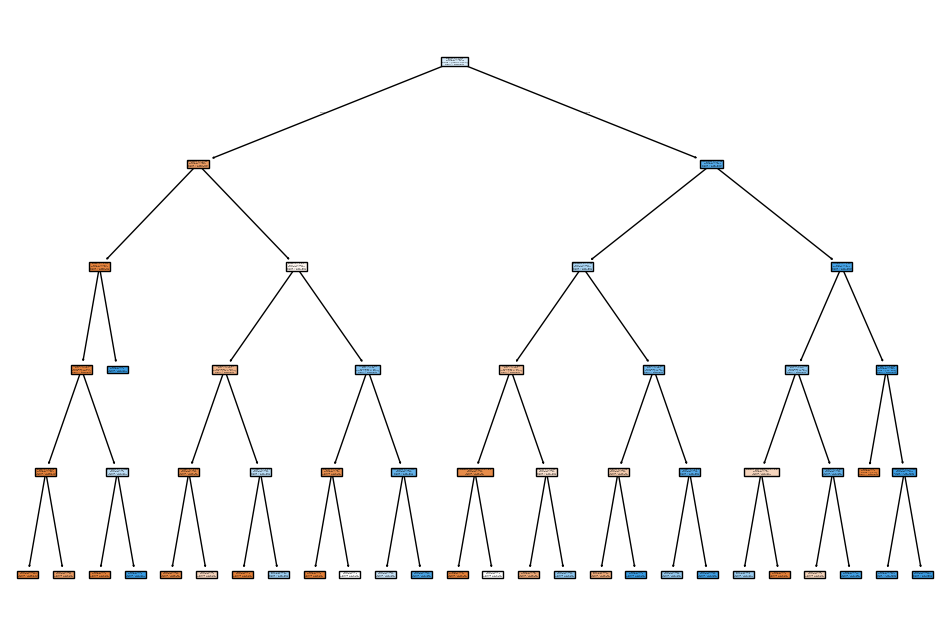

In [49]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
plot_tree(clf, filled=True, feature_names=df.columns, class_names=list(df['Specialty']))
plt.show()